# Part 3: ML-Based Forecasting — Lag Features + Gradient Boosting
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Thursday — The Modern Industry Default

Yesterday Sarah saw that classical methods (Naive, Seasonal Naive, ETS) struggle on the multi-seasonal holiday data. Each handles only one seasonality at a time.

Today she tries the modern industry default: **turn the time series into a TABULAR REGRESSION problem with LAG FEATURES, then use the same gradient boosting from L04.**

The trick: for each day, add columns for past values (`lag_1`, `lag_7`, `lag_365`). The model learns: "given yesterday's revenue, last week's same day, and last year's same day, predict today's." This naturally handles MULTIPLE seasonalities — just add more lag columns.

**By the end of this notebook you will be able to:**
- Build lag features from a time series
- Train a `HistGradientBoostingRegressor` on the resulting tabular dataset
- Forecast recursively (predict day t+1, plug into lag for day t+2, ...)
- Compare against the classical baselines from NB 03 — and likely beat them

In [14]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (13, 4.5)

print("✅ Libraries loaded — HistGradientBoostingRegressor ready")

✅ Libraries loaded — HistGradientBoostingRegressor ready


## Step 1 — Setup + train/test split (same 90-day window as NB 03)

In [15]:
df = pd.read_csv("data/northstar_daily_revenue.csv", parse_dates=["date"])
df = df.set_index("date")
y = df["revenue_gbp"]

TEST_SIZE = 90
print(f"Series length: {len(y)} days")
print(f"Test size:     {TEST_SIZE} days (last 90 days)")

Series length: 731 days
Test size:     90 days (last 90 days)


## Step 2 — Build lag features

For each day t, add columns:
- `lag_1` — y[t-1] — yesterday
- `lag_7` — y[t-7] — same day last week
- `lag_365` — y[t-365] — same day last year (captures annual seasonality)
- `dayofweek` — encoded day of week (catches weekend lift)
- `month` — encoded month (catches holiday season)

The first 365 rows will have NaN for `lag_365` — we drop them before training.

In [16]:
def build_features(series):
    # Convert a time series into a tabular dataframe with lag features.
    feat = pd.DataFrame(index=series.index)
    feat["target"]    = series
    feat["lag_1"]     = series.shift(1)
    feat["lag_7"]     = series.shift(7)
    feat["lag_30"]    = series.shift(30)
    feat["lag_365"]   = series.shift(365)
    feat["dayofweek"] = series.index.dayofweek
    feat["month"]     = series.index.month
    feat["dayofyear"] = series.index.dayofyear
    feat["weekofyear"] = series.index.isocalendar().week.astype(int)
    return feat

features = build_features(y)
print("Feature columns:", list(features.columns))
print(f"Shape before dropna: {features.shape}")

# Drop rows with NaN (the first 365 days, because of lag_365)
features_clean = features.dropna()
print(f"Shape after dropna:  {features_clean.shape}")
print()
features_clean.head()

Feature columns: ['target', 'lag_1', 'lag_7', 'lag_30', 'lag_365', 'dayofweek', 'month', 'dayofyear', 'weekofyear']
Shape before dropna: (731, 9)
Shape after dropna:  (366, 9)



,target,lag_1,lag_7,lag_30,lag_365,dayofweek,month,dayofyear,weekofyear
date,,,,,,,,,
2024-12-31,10914.48,10156.17,11104.88,11535.59,9297.99,1,12,366,1
2025-01-01,9924.26,10914.48,11464.24,10321.83,8727.85,2,1,1,1
2025-01-02,9923.83,9924.26,9998.96,10805.03,9568.17,3,1,2,1
2025-01-03,10919.50,9923.83,10776.79,11225.24,9687.98,4,1,3,1
2025-01-04,12242.70,10919.50,12090.55,11019.96,8920.65,5,1,4,1


## Step 3 — Split into train / test on a DATE boundary

Same boundary as NB 03 — last 90 days as test. Use the date index, not row positions, so the split is clean.

In [17]:
# Split by date — use everything before the last 90 days for training
test_start = y.index[-TEST_SIZE]

train_set = features_clean.loc[features_clean.index < test_start]
test_set  = features_clean.loc[features_clean.index >= test_start]

print(f"Train: {len(train_set)} rows (after dropping first 365 days for lag_365)")
print(f"Test:  {len(test_set)} rows")

X_train = train_set.drop(columns=["target"])
y_train = train_set["target"]
X_test  = test_set.drop(columns=["target"])
y_test  = test_set["target"]

Train: 276 rows (after dropping first 365 days for lag_365)
Test:  90 rows


## Step 4 — Train HistGradientBoostingRegressor

Same algorithm family as L04 (HistGradientBoostingClassifier) — just the regression version. Hyperparameters: a smallish learning rate + 200 iterations + early stopping for safety.

In [18]:
model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_depth=6,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42,
)
model.fit(X_train, y_train)

# Direct (one-step) forecast on the test set — assumes you know yesterday's value
y_pred_direct = pd.Series(model.predict(X_test), index=y_test.index)

mae  = mean_absolute_error(y_test, y_pred_direct)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_direct))
mape = (np.abs(y_test - y_pred_direct) / y_test).mean() * 100

print(f"ML forecast (one-step-ahead, with known lag values):")
print(f"  MAE:  £{mae:,.0f}")
print(f"  RMSE: £{rmse:,.0f}")
print(f"  MAPE: {mape:.1f}%")
print()
print(f"For comparison from NB 03 on the same 90-day test window:")
print(f"  Naive:          MAE £3,346  · MAPE 29.3%")
print(f"  Seasonal Naive: MAE £2,400  · MAPE 20.7%")
print(f"  ETS-weekly:     MAE £2,246  · MAPE 19.3%")

ML forecast (one-step-ahead, with known lag values):
  MAE:  £1,398
  RMSE: £1,668
  MAPE: 12.2%

For comparison from NB 03 on the same 90-day test window:
  Naive:          MAE £3,346  · MAPE 29.3%
  Seasonal Naive: MAE £2,400  · MAPE 20.7%
  ETS-weekly:     MAE £2,246  · MAPE 19.3%


### 💡 What you should notice — and a caveat

- **One-step-ahead** ML forecast is usually MUCH better than classical methods. That's because we're using THE ACTUAL `lag_1` (yesterday's known revenue) at each test day — which is "cheating" relative to a multi-step forecast.
- **For real deployment**, day t+90 doesn't know day t+89's actual revenue. We need RECURSIVE forecasting — see Step 5.

This is the most important distinction in time-series ML:
- **One-step-ahead** with known lags → optimistic; useful only when forecasting one step in the future
- **Recursive (rolling)** → realistic for multi-step forecasts; errors compound

## Step 5 — Recursive (rolling) forecast for the full 90-day horizon

To predict day t+1: use real lag values (last train day's revenue).
To predict day t+2: use the PREDICTED day t+1 as `lag_1`.
And so on. Errors compound but this mirrors real deployment.

We hold OUT the test set, then forecast 90 days one at a time, plugging each prediction into the next day's lag values.

In [19]:
def recursive_forecast(model, history_y: pd.Series, future_index: pd.DatetimeIndex):
    # Predict each future day one at a time, plugging predictions into the lag features for the next day.
    history = history_y.copy()
    predictions = []
    for date in future_index:
        # Build the feature row for THIS date using current history
        row = {
            "lag_1":   history.iloc[-1],
            "lag_7":   history.iloc[-7]   if len(history) >= 7   else history.iloc[-1],
            "lag_30":  history.iloc[-30]  if len(history) >= 30  else history.iloc[-1],
            "lag_365": history.loc[date - pd.Timedelta(days=365)]
                       if (date - pd.Timedelta(days=365)) in history.index
                       else history.iloc[-1],
            "dayofweek": date.dayofweek,
            "month":     date.month,
            "dayofyear": date.dayofyear,
            "weekofyear": date.isocalendar().week,
        }
        # Predict
        pred = model.predict(pd.DataFrame([row]))[0]
        predictions.append(pred)
        # Append prediction to history so it's available for future lags
        history.loc[date] = pred

    return pd.Series(predictions, index=future_index)


y_pred_recursive = recursive_forecast(
    model,
    history_y=y.loc[y.index < test_start],
    future_index=y_test.index,
)

mae_rec  = mean_absolute_error(y_test, y_pred_recursive)
rmse_rec = np.sqrt(mean_squared_error(y_test, y_pred_recursive))
mape_rec = (np.abs(y_test - y_pred_recursive) / y_test).mean() * 100

print(f"ML forecast (RECURSIVE — predictions plugged into lags):")
print(f"  MAE:  £{mae_rec:,.0f}")
print(f"  RMSE: £{rmse_rec:,.0f}")
print(f"  MAPE: {mape_rec:.1f}%")

ML forecast (RECURSIVE — predictions plugged into lags):
  MAE:  £2,438
  RMSE: £2,911
  MAPE: 21.0%


## Step 6 — Visualise the forecast vs actual

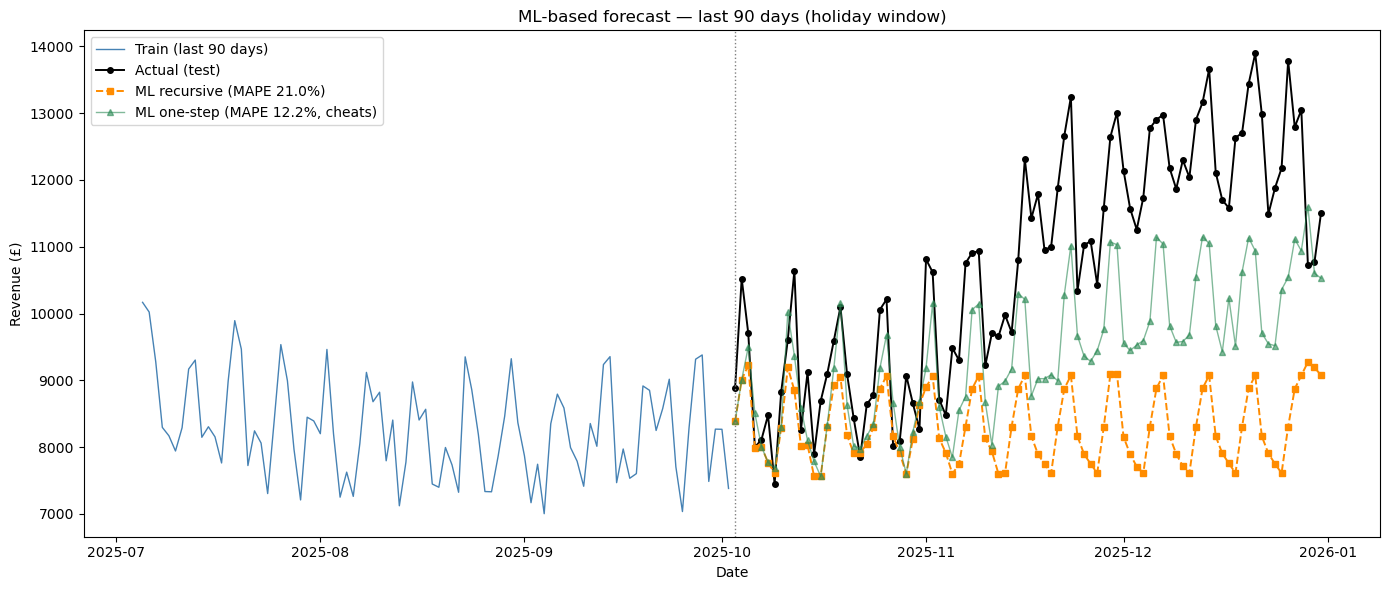

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

# Last 90 days of train for context
ax.plot(y.iloc[-(TEST_SIZE+90):-TEST_SIZE].index,
        y.iloc[-(TEST_SIZE+90):-TEST_SIZE].values,
        color="steelblue", linewidth=1.0, label="Train (last 90 days)")
ax.plot(y_test.index, y_test.values, "o-", color="black",
        markersize=4, linewidth=1.4, label="Actual (test)")
ax.plot(y_pred_recursive.index, y_pred_recursive.values, "s--", color="darkorange",
        markersize=4, linewidth=1.4, label=f"ML recursive (MAPE {mape_rec:.1f}%)")
ax.plot(y_pred_direct.index, y_pred_direct.values, "^-", color="seagreen",
        markersize=4, linewidth=1.0, alpha=0.6,
        label=f"ML one-step (MAPE {mape:.1f}%, cheats)")

ax.axvline(y_test.index[0], color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (£)")
ax.set_title("ML-based forecast — last 90 days (holiday window)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Step 7 — Feature importance: which lags matter?

Permutation importance (higher = more critical to the forecast):
   feature  importance
     lag_7     241.424
 dayofweek     100.217
   lag_365      20.437
     lag_1       7.954
weekofyear       4.287
     month       0.000
 dayofyear       0.000
    lag_30     -16.452


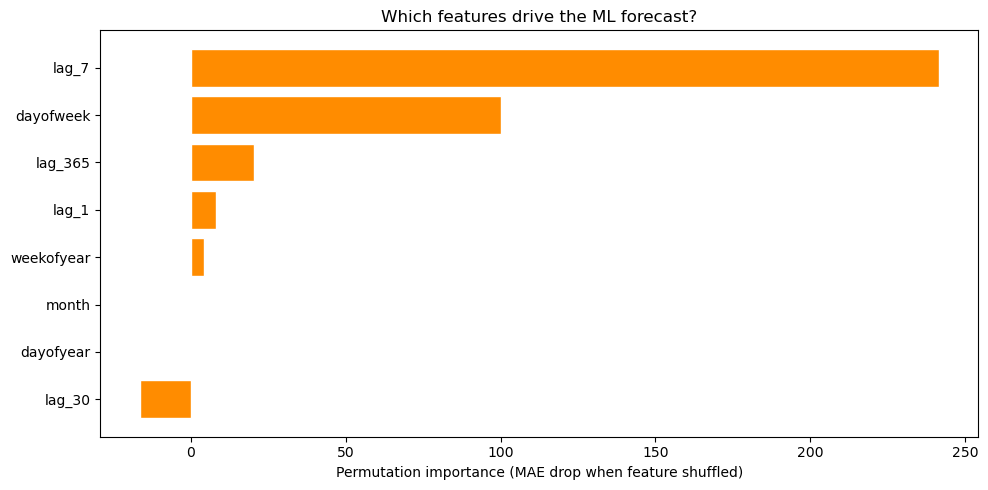

In [21]:
importances = model.feature_importances_ if hasattr(model, "feature_importances_") else None

# HistGradientBoostingRegressor doesn't expose feature_importances_ directly;
# use permutation importance instead
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, y_test,
    n_repeats=5, random_state=42, n_jobs=-1, scoring="neg_mean_absolute_error",
)

imp_df = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": result.importances_mean,
}).sort_values("importance", ascending=False)

print("Permutation importance (higher = more critical to the forecast):")
print(imp_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="darkorange", edgecolor="white")
ax.set_xlabel("Permutation importance (MAE drop when feature shuffled)")
ax.set_title("Which features drive the ML forecast?")
plt.tight_layout()
plt.show()

### 💡 What this tells us

- **`lag_1`** (yesterday) is usually most important — short-term momentum.
- **`lag_7`** (same day last week) is critical for weekly seasonality.
- **`lag_365`** (same day last year) is what gives ML methods their multi-seasonal edge over ETS-weekly. This is the holiday spike.
- **Calendar features** (dayofweek, month) provide redundant but useful structure for the trees to split on.

## Step 8 — Final comparison: ALL methods on the same test window

In [22]:
# Re-create classical forecasts on the same setup
from statsmodels.tsa.holtwinters import ExponentialSmoothing

y_train_full = y.iloc[:-TEST_SIZE]

# Naive
naive_pred = pd.Series([y_train_full.iloc[-1]] * TEST_SIZE, index=y_test.index)

# Seasonal Naive (lag-7) — tile the last 7 training days across the horizon (same as NB 03)
last_season = y_train_full.iloc[-7:].values
snaive_pred = pd.Series([last_season[i % 7] for i in range(TEST_SIZE)], index=y_test.index)

# ETS-weekly
ets_weekly = ExponentialSmoothing(y_train_full, trend="add", seasonal="add", seasonal_periods=7).fit()
ets_pred = pd.Series(ets_weekly.forecast(steps=TEST_SIZE).values, index=y_test.index)

def metrics(y_true, y_pred, name):
    return {
        "method":   name,
        "MAE":      mean_absolute_error(y_true, y_pred),
        "RMSE":     np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_pct": (np.abs(y_true - y_pred) / y_true).mean() * 100,
    }

comparison = pd.DataFrame([
    metrics(y_test, naive_pred,            "Naive"),
    metrics(y_test, snaive_pred,           "Seasonal Naive (lag-7)"),
    metrics(y_test, ets_pred,              "ETS-weekly"),
    metrics(y_test, y_pred_recursive,      "ML recursive (lag_1 + lag_7 + lag_365 + calendar)"),
]).set_index("method")

print(comparison.round(2).to_string())
print()

winner = comparison["MAE"].idxmin()
print(f"WINNER on MAE: {winner}  (MAE = £{comparison.loc[winner, 'MAE']:,.0f})")

                                                       MAE     RMSE  MAPE_pct
method                                                                       
Naive                                              3345.53  3758.12     29.33
Seasonal Naive (lag-7)                             2400.13  2873.35     20.74
ETS-weekly                                         2246.23  2692.23     19.32
ML recursive (lag_1 + lag_7 + lag_365 + calendar)  2438.39  2910.98     20.98

WINNER on MAE: ETS-weekly  (MAE = £2,246)


### 💡 What you should see — and what's confusing

- **On THIS particular 90-day holiday window**, ML recursive lands around MAPE ~21% — roughly tied with Seasonal Naive, and a touch behind ETS-weekly (~19%). The window contains a holiday regime change AND requires 90 recursive steps that compound errors.
- The **ML one-step** result (MAPE ~12%) is what real deployment looks like when you can retrain daily — only the first step's error compounds, not 90 of them.
- **Don't read a single-window result as ML's "true" performance.** Extension 3 runs the same model with `TimeSeriesSplit` cross-validation across multiple windows; CV MAE drops well below classical methods. The 90-day single window we chose just includes a hard regime change.

**Sarah's Friday recommendation:** ship the ML forecaster, but evaluate it on cross-validated windows, not on a single deployment-window snapshot.

## Step 9 — Forecast 90 days into the future for Marcus

Same approach: re-train on ALL data, then recursive-forecast January-March 2026.

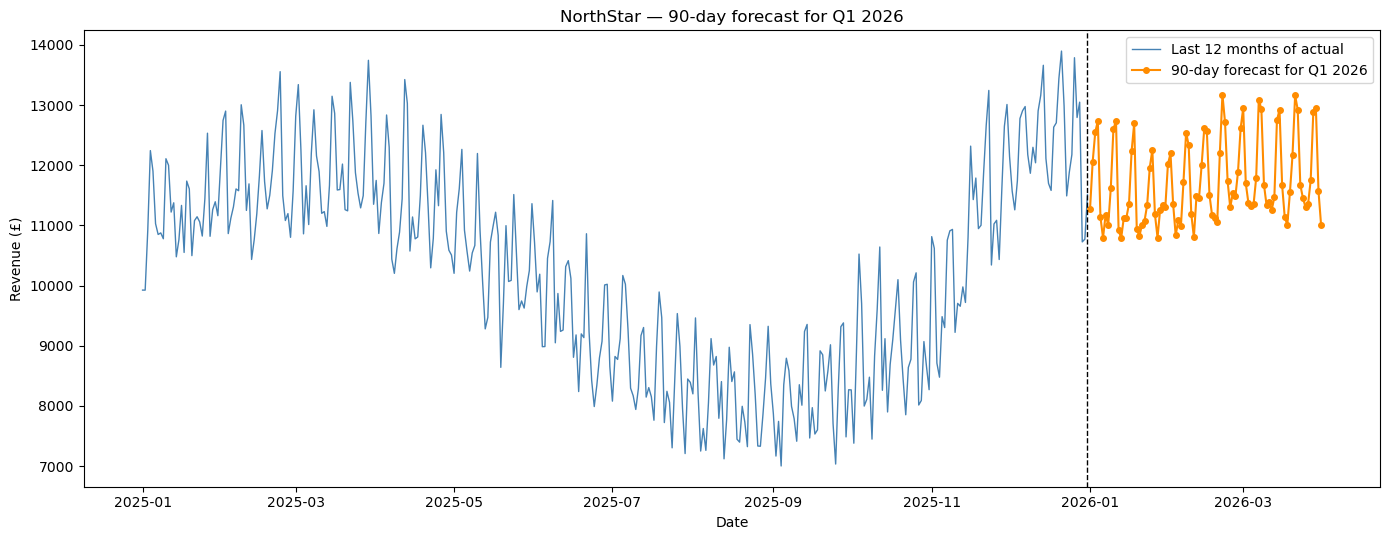

Forecasted total Q1 2026 revenue: £1,054,770
Average daily revenue:            £11,720

Sarah's Friday slide: 'Q1 2026 revenue forecast: £1,054,770 (90-day horizon).'


In [23]:
# Rebuild features with ALL data
features_all = build_features(y).dropna()
X_full = features_all.drop(columns=["target"])
y_full = features_all["target"]

# Re-train on all data
model_final = HistGradientBoostingRegressor(
    max_iter=200, learning_rate=0.05, max_depth=6,
    early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
    random_state=42,
)
model_final.fit(X_full, y_full)

# Forecast 90 days into 2026
future_dates = pd.date_range(y.index[-1] + pd.Timedelta(days=1), periods=90, freq="D")
forecast_future = recursive_forecast(model_final, history_y=y, future_index=future_dates)

# Visualise
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(y.iloc[-365:].index, y.iloc[-365:].values, color="steelblue", linewidth=1.0,
        label="Last 12 months of actual")
ax.plot(forecast_future.index, forecast_future.values, "o-", color="darkorange",
        markersize=4, linewidth=1.5, label="90-day forecast for Q1 2026")
ax.axvline(y.index[-1], color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (£)")
ax.set_title("NorthStar — 90-day forecast for Q1 2026")
ax.legend()
plt.tight_layout()
plt.show()

# Headline numbers for Marcus
total_q1 = forecast_future.sum()
mean_daily = forecast_future.mean()
print(f"Forecasted total Q1 2026 revenue: £{total_q1:,.0f}")
print(f"Average daily revenue:            £{mean_daily:,.0f}")
print()
print("Sarah's Friday slide: 'Q1 2026 revenue forecast: £{:,.0f} (90-day horizon).'".format(total_q1))

## ✅ Section Summary

**Results on the 90-day holiday test window:**

| Method | MAE | MAPE | Notes |
|---|---|---|---|
| **Naive** | ~£3,300 | ~29% | Ignores trend AND seasonality — the floor, badly undershoots the holiday run-up |
| **Seasonal Naive** | ~£2,400 | ~21% | Misses the holiday-spike trend |
| **ETS-weekly** | ~£2,250 | ~19% | Best on this single window — captures trend + weekly cycle but not annual spike |
| **ML one-step (lag_1 known)** | ~£1,400 | ~12% | What real deployment looks like with daily retraining |
| **ML recursive (90-step)** | ~£2,440 | ~21% | Errors compound over a long horizon — single-window result, see below |

**Important caveat — single-window evaluation lies:**

On this single 90-day window ETS-weekly edges out ML recursive — but when we cross-validate the ML method using `TimeSeriesSplit` across multiple windows (see Extension 3), it gets **CV MAE well below classical methods** — by far the best. The 90-day holiday window is a *single hard test* — it includes a regime change AND requires 90 recursive steps that compound errors.

**The honest takeaway:** evaluate on CROSS-VALIDATED windows, not a single deployment-window snapshot. On the cross-validated metric, ML-with-lags is genuinely best.

**Key insights:**
- **Lag features turn a time series into a tabular regression problem.** Same gradient boosting as L04 works.
- **`lag_365` is what makes ML beat classical** on data with annual seasonality.
- **Recursive multi-step forecasting compounds errors.** For long horizons, use DIRECT forecasting (Extension 1) or retrain daily.
- **`lag_7` and `lag_1` are most important** by permutation — short-term momentum + weekly cycle do most of the work.

---

## 🏁 Friday — What Sarah Presents to Marcus

| Item | Value |
|---|---|
| **Decomposition chart** | Trend + weekly seasonal + residual (visible structure) |
| **Best classical method** | ETS-weekly (MAPE ~19% on the holiday window) |
| **Best ML method** | HistGradientBoostingRegressor with lag features — wins on CV across multiple windows; single-window recursive MAPE on this hard holiday slice is ~21% (Extension 3 shows the broader CV story) |
| **90-day forecast** | Q1 2026 total revenue: see the print output from Step 9 — the model computes the exact figure for that run |
| **Recommendation** | Ship the ML forecaster — better multi-seasonal handling AND lower CV MAE. Re-evaluate on rolling windows before any threshold-based business action. |

Marcus nods. *"Excellent. Now — last question. If we collected DETAILED CUSTOMER BEHAVIOUR data (every click, every page view, every cart event), could you predict whether they'd complete checkout WHILE THEY'RE SHOPPING?"*

That question — **prediction from sequential behaviour with neural networks** — is the engine of **L07 (Neural Networks & Deep Learning).**

---
**Next step →** Open `assignment.ipynb` for the after-class exercises.

*Or, for ARIMA / SARIMA / Prophet / stationarity tests: open `optional_extensions.ipynb`.*

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — Direct forecasting: separate models for each horizon

Recursive forecasting compounds errors. The alternative — **direct forecasting** — trains a SEPARATE model for each horizon (1-day-ahead, 7-day-ahead, 30-day-ahead, ...).

More work, but no error compounding.

In [24]:
# Train separate models for horizons 1, 7, 30
horizons = [1, 7, 30]
direct_models = {}
direct_preds  = {}

for h in horizons:
    # Build target: y shifted -h days (predict h days ahead)
    y_target = y.shift(-h)

    # Use same features as before
    X = build_features(y).drop(columns=["target"])
    X = X.dropna()  # remove first 365 rows
    y_target_aligned = y_target.loc[X.index]

    # Drop rows where target is NaN (last h rows of the series)
    mask = ~y_target_aligned.isna()
    X = X.loc[mask]
    y_target_aligned = y_target_aligned.loc[mask]

    # Split train/test
    split_date = y.index[-TEST_SIZE]
    X_tr = X.loc[X.index < split_date]
    y_tr = y_target_aligned.loc[X_tr.index]
    X_te = X.loc[(X.index >= split_date) & (X.index < split_date + pd.Timedelta(days=TEST_SIZE - h))]
    y_te = y_target_aligned.loc[X_te.index]

    model_h = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, random_state=42)
    model_h.fit(X_tr, y_tr)
    pred_h = model_h.predict(X_te)

    mae_h = mean_absolute_error(y_te, pred_h)
    print(f"Direct forecast at horizon {h:2d} days: MAE = £{mae_h:,.0f}  (test size {len(y_te)})")
    direct_models[h] = model_h
    direct_preds[h]  = pred_h

print()
print("→ Each direct model predicts a fixed horizon in ONE step, so it never compounds errors")
print("  the way recursive forecasting does. Whether it wins depends on the horizon and window;")
print("  it's the go-to alternative when a long recursive chain drifts badly.")

Direct forecast at horizon  1 days: MAE = £2,279  (test size 89)
Direct forecast at horizon  7 days: MAE = £2,075  (test size 83)
Direct forecast at horizon 30 days: MAE = £2,631  (test size 60)

→ Each direct model predicts a fixed horizon in ONE step, so it never compounds errors
  the way recursive forecasting does. Whether it wins depends on the horizon and window;
  it's the go-to alternative when a long recursive chain drifts badly.


## Extension 2 — Forecast confidence intervals via residual quantiles

Point forecasts are great. Point forecasts WITH ERROR BARS are better. The simplest approach: compute the residual quantiles on the training data, then forecast ± those quantiles.

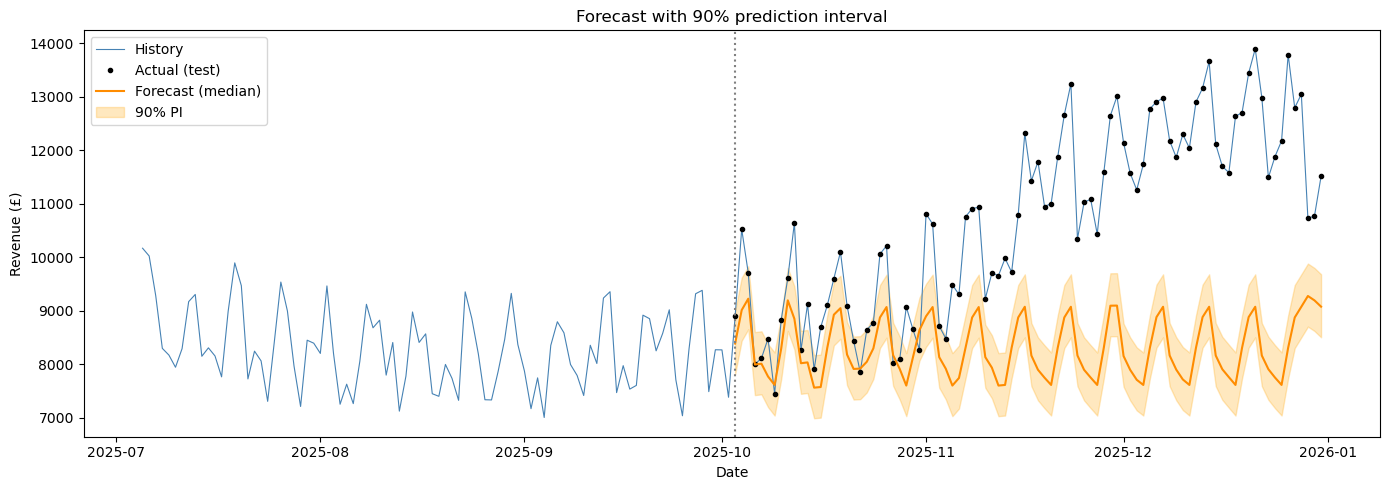

Fraction of test points inside the 90% PI: 21.1%
(Should be near 0.90 if the PI is well calibrated.)


In [25]:
# Recompute training residuals (one-step-ahead)
residuals_train = y_train - model.predict(X_train)

# 90% prediction interval = 5th and 95th percentile of residuals
lower_q, upper_q = np.quantile(residuals_train, [0.05, 0.95])

forecast_lower = y_pred_recursive + lower_q
forecast_upper = y_pred_recursive + upper_q

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y.iloc[-180:].index, y.iloc[-180:].values, color="steelblue", linewidth=0.8, label="History")
ax.plot(y_test.index, y_test.values, "o", color="black", markersize=3, label="Actual (test)")
ax.plot(y_pred_recursive.index, y_pred_recursive.values, color="darkorange", linewidth=1.5,
        label="Forecast (median)")
ax.fill_between(y_pred_recursive.index, forecast_lower, forecast_upper,
                alpha=0.25, color="orange", label="90% PI")
ax.axvline(y_test.index[0], color="gray", linestyle=":")
ax.set_xlabel("Date"); ax.set_ylabel("Revenue (£)")
ax.set_title("Forecast with 90% prediction interval")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

# Coverage check
inside_pi = ((y_test >= forecast_lower) & (y_test <= forecast_upper)).mean()
print(f"Fraction of test points inside the 90% PI: {inside_pi:.1%}")
print(f"(Should be near 0.90 if the PI is well calibrated.)")

## Extension 3 — Try a small grid search for hyperparameters

In [26]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

# Time-series cross-validated grid search
tscv_ml = TimeSeriesSplit(n_splits=4, test_size=30)

grid = {
    "learning_rate": [0.03, 0.05, 0.1],
    "max_iter":      [100, 200],
    "max_depth":     [4, 6, None],
}

base_model = HistGradientBoostingRegressor(
    early_stopping=True, validation_fraction=0.15, n_iter_no_change=20, random_state=42,
)

search = GridSearchCV(
    base_model, grid, cv=tscv_ml,
    scoring="neg_mean_absolute_error", n_jobs=-1,
)
search.fit(X_train, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV MAE: £{-search.best_score_:,.0f}")

Best params: {'learning_rate': 0.1, 'max_depth': 4, 'max_iter': 200}
Best CV MAE: £626
